<a href="https://colab.research.google.com/github/JoaoLopesMendes/Projeto-IA-ENEM-2023/blob/main/notebookartigofinalizado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset carregado: 367283 registros.
Registros válidos: 272998

Distribuição da superação acadêmica:
SUPERACAO_ACADEMICA
0    66617
1     7406
Name: count, dtype: int64


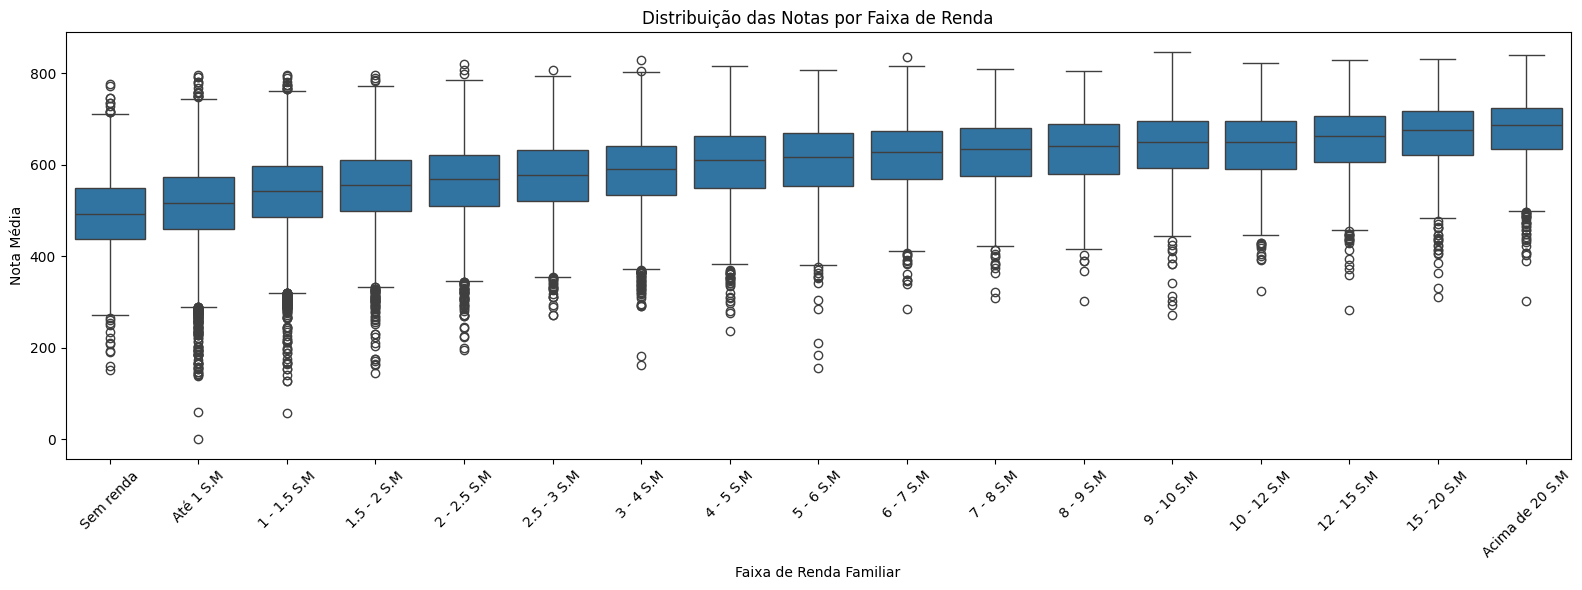

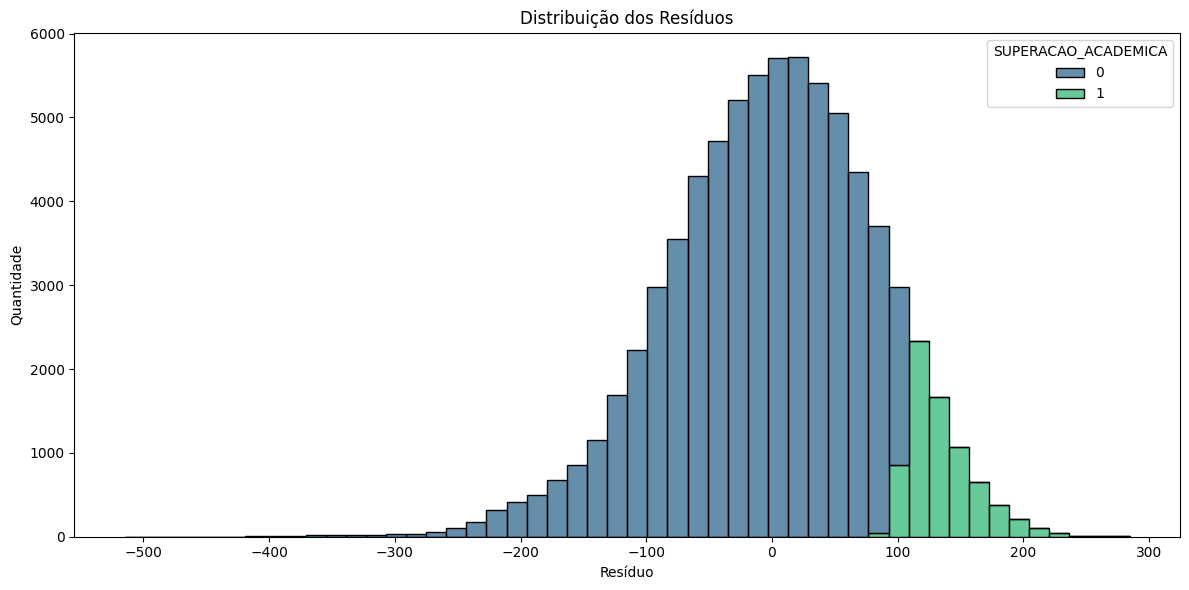


=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.93      0.66      0.77     13324
           1       0.16      0.56      0.24      1481

    accuracy                           0.65     14805
   macro avg       0.54      0.61      0.51     14805
weighted avg       0.85      0.65      0.72     14805

ROC-AUC: 0.6556
ROC-AUC médio CV: 0.6457


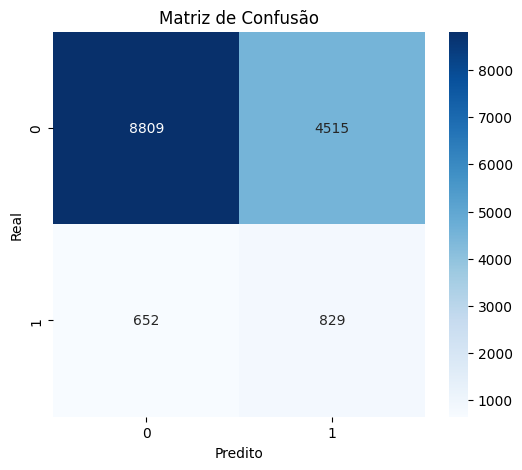

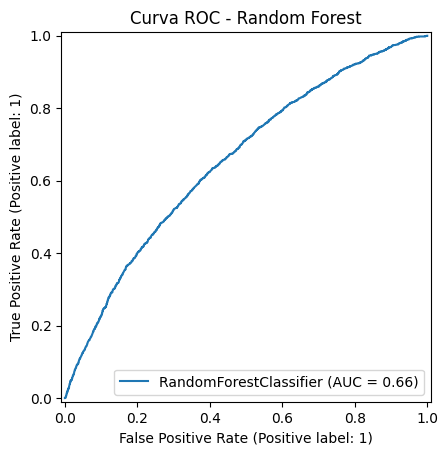


=== IMPACTO DAS VARIÁVEIS ===
                  Variavel  Importancia
6                TP_ESCOLA     0.301987
8                     Q005     0.117225
10           TP_COR_RACA_1     0.096139
1          ESTUDOS_MAE_NUM     0.094203
2       PAIS_ALTOS_ESTUDOS     0.072076
0          ESTUDOS_PAI_NUM     0.069522
7          TP_FAIXA_ETARIA     0.068887
4           COMPUTADOR_NUM     0.052617
9                TP_SEXO_M     0.046502
5             SEM_RECURSOS     0.021149
12           TP_COR_RACA_3     0.019893
11           TP_COR_RACA_2     0.013983
3             INTERNET_NUM     0.013958
15  TP_LOCALIZACAO_ESC_2.0     0.005724
13           TP_COR_RACA_4     0.004245


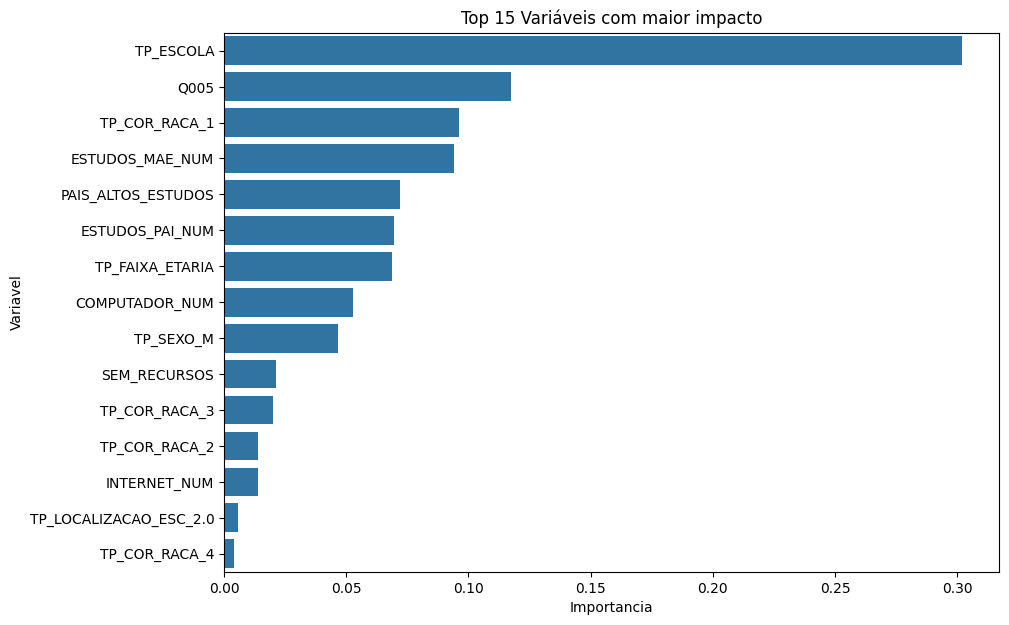


=== REGRESSÃO LOGÍSTICA ===
              precision    recall  f1-score   support

           0       0.93      0.65      0.76     13324
           1       0.15      0.55      0.24      1481

    accuracy                           0.64     14805
   macro avg       0.54      0.60      0.50     14805
weighted avg       0.85      0.64      0.71     14805

ROC-AUC da Regressão Logística: 0.6433

=== COMPARAÇÃO FINAL ===
                Modelo   ROC_AUC  ROC_AUC_CV
0        Random Forest  0.655632    0.645697
1  Regressão Logística  0.643325         NaN

Pipeline concluído com sucesso.
Dataset exportado.


In [2]:
#------------------------------------------------------------------------------
# Bibliotecas importadas
#------------------------------------------------------------------------------

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#------------------------------------------------------------------------------
# Os Modelos de Machine Learning que serão utilizados
#------------------------------------------------------------------------------

# Random Forest:
# Modelo baseado em múltiplas árvores de decisão.
from sklearn.ensemble import RandomForestClassifier

# Regressão Logística:
# Modelo estatístico usado para classificação binária.
from sklearn.linear_model import LogisticRegression

#------------------------------------------------------------------------------
# Ferramentas auxiliares
#------------------------------------------------------------------------------

# train_test_split: Divide os dados entre treino e teste.
#
# cross_val_score: Faz validação cruzada do modelo.
from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

# OrdinalEncoder: Transforma categorias em números.
from sklearn.preprocessing import OrdinalEncoder

# Métricas para avaliação do modelo.
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

#------------------------------------------------------------------------------
# 1. Carregamento dos microdados
#------------------------------------------------------------------------------

# Caminho do dataset do ENEM.
caminho = '/content/MICRODADOS_ENEM_2023.csv'

# Leitura do CSV.
df = pd.read_csv(
    caminho,
    sep=';',
    encoding='latin-1',
    nrows=400000 # Os microdados do ENEM possuem um volume elevado de informações. Devido às limitações de memória e processamento do Google Colab, foi possível carregar apenas 270.000 registros para a realização das análises
)

print(f"Dataset carregado: {df.shape[0]} registros.")

#------------------------------------------------------------------------------
# 2. Filtragem dos participantes Válidos
#------------------------------------------------------------------------------

# Mantém apenas alunos presentes em todas as provas objetivas.
df_validos = df[
    (df['TP_PRESENCA_CN'] == 1) &
    (df['TP_PRESENCA_CH'] == 1) &
    (df['TP_PRESENCA_LC'] == 1) &
    (df['TP_PRESENCA_MT'] == 1)
].copy()

print(f"Registros válidos: {df_validos.shape[0]}")

#------------------------------------------------------------------------------
# 3. Cálculo da Nota Média
#------------------------------------------------------------------------------

# Notas utilizadas para cálculo da média final.
colunas_notas = [
    'NU_NOTA_CN',
    'NU_NOTA_CH',
    'NU_NOTA_LC',
    'NU_NOTA_MT',
    'NU_NOTA_REDACAO'
]

# Média geral do participante.
df_validos['NOTA_MEDIA'] = df_validos[colunas_notas].mean(axis=1)

#------------------------------------------------------------------------------
# 4. Limpeza de dados
#------------------------------------------------------------------------------

# Remove registros com informações faltando nas seguintes colunas
df_validos = df_validos.dropna(
    subset=[
        'Q006',                    # Faixa de renda familiar
        'Q001',                    # Escolaridade do pai
        'Q002',                    # Escolaridade da mãe
        'Q024',                    # Possui computador
        'Q025',                    # Possui internet
        'TP_ESCOLA',               # Tipo de escola
        'TP_FAIXA_ETARIA',         # Faixa etária
        'TP_SEXO',                 # Sexo
        'TP_COR_RACA',             # Cor/raça
        'TP_LOCALIZACAO_ESC',      # Localização da escola
        'TP_ST_CONCLUSAO',         # Situação escolar
        'Q005'                     # Quantidade de pessoas na residência
    ]
)

#------------------------------------------------------------------------------
# 5. Transformação Ordinal
#------------------------------------------------------------------------------

# Ordem das categorias de renda do ENEM.
categorias_renda = [
    'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H',
    'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q'
]

# Ordem da escolaridade dos pais.
categorias_estudos = [
    'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'
]

# Conversão de categorias em valores numéricos.
encoder = OrdinalEncoder(
    categories=[
        categorias_renda,
        categorias_estudos,
        categorias_estudos
    ]
)

df_validos[
    ['RENDA_NUM', 'ESTUDOS_PAI_NUM', 'ESTUDOS_MAE_NUM']
] = encoder.fit_transform(
    df_validos[['Q006', 'Q001', 'Q002']]
)

#------------------------------------------------------------------------------
# 6. Variáveis Binárias
#------------------------------------------------------------------------------

# INTERNET_NUM:
# 0 = não possui internet
# 1 = possui internet
df_validos['INTERNET_NUM'] = df_validos['Q025'].map({
    'A': 0,
    'B': 1
}).fillna(0)

# COMPUTADOR_NUM:
# 0 = não possui computador
# 1 = possui computador
df_validos['COMPUTADOR_NUM'] = df_validos['Q024'].map({
    'A': 0,
    'B': 1
}).fillna(0)

#------------------------------------------------------------------------------
# 7. Tratamento do tipo de escola
#------------------------------------------------------------------------------

# TP_ESCOLA:
# 0 = não respondeu / não se aplica
# 1 = escola pública
# 2 = escola privada
df_validos['TP_ESCOLA'] = df_validos['TP_ESCOLA'].replace({
    1: 0,
    2: 1,
    3: 2
})

#------------------------------------------------------------------------------
# 8. Feature Engineering
#------------------------------------------------------------------------------

# Média da escolaridade dos pais.
# Quanto maior, maior tende a ser o apoio educacional familiar.
df_validos['PAIS_ALTOS_ESTUDOS'] = (
    (
        df_validos['ESTUDOS_PAI_NUM'] +
        df_validos['ESTUDOS_MAE_NUM']
    ) / 2
)

# SEM_RECURSOS:
# 1 = sem internet e sem computador
# 0 = possui pelo menos um dos recursos
df_validos['SEM_RECURSOS'] = (
    (df_validos['INTERNET_NUM'] == 0) &
    (df_validos['COMPUTADOR_NUM'] == 0)
).astype(int)

#------------------------------------------------------------------------------
# 9. Baseline por faixa de renda
#------------------------------------------------------------------------------

# Calcula a média de nota para cada faixa de renda.
media_por_renda = df_validos.groupby(
    'RENDA_NUM'
)['NOTA_MEDIA'].mean()

# Define a nota esperada de acordo com a renda.
df_validos['NOTA_ESPERADA'] = df_validos[
    'RENDA_NUM'
].map(media_por_renda)

# Resíduo:
# Diferença entre nota real e nota esperada. (tanto positivo quanto negativo)
#
# Resíduo positivo:
# aluno foi melhor que a média da própria faixa de renda.
df_validos['RESIDUO'] = (
    df_validos['NOTA_MEDIA'] -
    df_validos['NOTA_ESPERADA']
)

#------------------------------------------------------------------------------
# 10. Definição de Superação Acadêmica
#------------------------------------------------------------------------------

# Inicializa a variável alvo.
df_validos['SUPERACAO_ACADEMICA'] = 0

# Para cada faixa de renda:
# seleciona os alunos com maiores resíduos.
for renda in df_validos['RENDA_NUM'].unique():

    mask = df_validos['RENDA_NUM'] == renda

    # Top 10% de desempenho relativo dentro da renda.
    limite = df_validos.loc[
        mask,
        'RESIDUO'
    ].quantile(0.90)

    # Marca alunos com superação acadêmica.
    df_validos.loc[
        mask &
        (df_validos['RESIDUO'] > limite),
        'SUPERACAO_ACADEMICA'
    ] = 1

print("\nDistribuição da superação acadêmica:")
print(df_validos['SUPERACAO_ACADEMICA'].value_counts())

#------------------------------------------------------------------------------
# 11. VISUALIZAÇÃO DAS NOTAS POR RENDA
#------------------------------------------------------------------------------

# Tradução das categorias de renda.
mapa_renda = {
    'A': 'Sem renda',
    'B': 'Até 1 S.M',
    'C': '1 - 1.5 S.M',
    'D': '1.5 - 2 S.M',
    'E': '2 - 2.5 S.M',
    'F': '2.5 - 3 S.M',
    'G': '3 - 4 S.M',
    'H': '4 - 5 S.M',
    'I': '5 - 6 S.M',
    'J': '6 - 7 S.M',
    'K': '7 - 8 S.M',
    'L': '8 - 9 S.M',
    'M': '9 - 10 S.M',
    'N': '10 - 12 S.M',
    'O': '12 - 15 S.M',
    'P': '15 - 20 S.M',
    'Q': 'Acima de 20 S.M'
}

# Cria labels mais legíveis.
df_validos['FAIXA_RENDA_LABEL'] = df_validos['Q006'].map(
    mapa_renda
)

# Ordem correta das categorias.
ordem_renda = [
    'Sem renda',
    'Até 1 S.M',
    '1 - 1.5 S.M',
    '1.5 - 2 S.M',
    '2 - 2.5 S.M',
    '2.5 - 3 S.M',
    '3 - 4 S.M',
    '4 - 5 S.M',
    '5 - 6 S.M',
    '6 - 7 S.M',
    '7 - 8 S.M',
    '8 - 9 S.M',
    '9 - 10 S.M',
    '10 - 12 S.M',
    '12 - 15 S.M',
    '15 - 20 S.M',
    'Acima de 20 S.M'
]

# Boxplot das notas por renda.
plt.figure(figsize=(16, 6))

sns.boxplot(
    data=df_validos,
    x='FAIXA_RENDA_LABEL',
    y='NOTA_MEDIA',
    order=ordem_renda
)

plt.xticks(rotation=45)

plt.title('Distribuição das Notas por Faixa de Renda')
plt.xlabel('Faixa de Renda Familiar')
plt.ylabel('Nota Média')

plt.tight_layout()
plt.show()

#------------------------------------------------------------------------------
# 12. Distribuição dos resíduos
#------------------------------------------------------------------------------

# Mostra a distribuição dos resíduos.
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df_validos,
    x='RESIDUO',
    hue='SUPERACAO_ACADEMICA',
    bins=50,
    palette='viridis',
    multiple='stack'
)

plt.title('Distribuição dos Resíduos')
plt.xlabel('Resíduo')
plt.ylabel('Quantidade')

plt.tight_layout()
plt.show()

#------------------------------------------------------------------------------
# 13. Features do modelo
#------------------------------------------------------------------------------

# Variáveis utilizadas pelo modelo
features_inferencia = [

    # Escolaridade do pai
    'ESTUDOS_PAI_NUM',

    # Escolaridade da mãe
    'ESTUDOS_MAE_NUM',

    # Média da escolaridade dos pais
    'PAIS_ALTOS_ESTUDOS',

    # Possui internet em casa
    'INTERNET_NUM',

    # Possui computador
    'COMPUTADOR_NUM',

    # Não possui internet nem computador
    'SEM_RECURSOS',

    # Tipo de escola
    # 1 = pública
    # 2 = privada
    'TP_ESCOLA',

    # Faixa etária do participante
    'TP_FAIXA_ETARIA',

    # Sexo do participante
    'TP_SEXO',

    # Cor/raça autodeclarada
    'TP_COR_RACA',

    # Localização da escola:
    # urbana ou rural.
    'TP_LOCALIZACAO_ESC',

    # Situação escolar do aluno
    'TP_ST_CONCLUSAO',

    # Quantidade de pessoas na residência, casas muito cheias podem indicar:
    # menor renda per capita, menos ambientes de estudo, mais responsabilidades domésticas.
    'Q005'
]

#------------------------------------------------------------------------------
# 14. Base final do modelo
#------------------------------------------------------------------------------

# Cria dataset final do modelo.
df_modelo = df_validos[
    features_inferencia +
    ['SUPERACAO_ACADEMICA']
].copy()

#------------------------------------------------------------------------------
# 15. One hot encoding
#------------------------------------------------------------------------------

# Converte categorias em colunas binárias
df_modelo = pd.get_dummies(
    df_modelo,
    columns=[
        'TP_SEXO',
        'TP_COR_RACA',
        'TP_LOCALIZACAO_ESC',
        'TP_ST_CONCLUSAO'
    ],
    drop_first=True
)

#------------------------------------------------------------------------------
# 16. Definição de x e y
#------------------------------------------------------------------------------

# Variáveis de entrada.
X_ia = df_modelo.drop(
    columns=['SUPERACAO_ACADEMICA']
)

# Variável alvo.
y_ia = df_modelo['SUPERACAO_ACADEMICA']

#------------------------------------------------------------------------------
# 17. Divisão Treino/Teste
#------------------------------------------------------------------------------

# 80% treino / 20% teste.
X_train, X_test, y_train, y_test = train_test_split(
    X_ia,
    y_ia,
    test_size=0.2,
    random_state=42,
    stratify=y_ia
)

#------------------------------------------------------------------------------
# 18. Random Forest
#------------------------------------------------------------------------------

# Configuração do modelo Random Forest
modelo_rf = RandomForestClassifier(
    n_estimators=800,
    max_depth=8,
    min_samples_leaf=10,
    min_samples_split=20,
    class_weight='balanced',
    random_state=42
)

# Treinamento do modelo
modelo_rf.fit(X_train, y_train)

#------------------------------------------------------------------------------
# 19. Predições do Random Forest
#------------------------------------------------------------------------------

# Classes previstas.
y_pred_rf = modelo_rf.predict(X_test)

# Probabilidades previstas.
y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

#------------------------------------------------------------------------------
# 20. Métricas do Random Forest
#------------------------------------------------------------------------------

print("\n=== RANDOM FOREST ===")

# Relatório completo de métricas.
print(classification_report(
    y_test,
    y_pred_rf
))

# ROC-AUC:
# Mede a capacidade do modelo separar as classes.
auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

print(f"ROC-AUC: {auc_rf:.4f}")

#------------------------------------------------------------------------------
# 21. Validação Cruzada
#------------------------------------------------------------------------------

# Mede estabilidade do modelo em múltiplas divisões.
scores_rf = cross_val_score(
    modelo_rf,
    X_ia,
    y_ia,
    cv=5,
    scoring='roc_auc'
)

print(f"ROC-AUC médio CV: {scores_rf.mean():.4f}")

#------------------------------------------------------------------------------
# 22. Matriz de Confusão
#------------------------------------------------------------------------------

# Mostra acertos e erros do modelo
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusão')
plt.xlabel('Predito')
plt.ylabel('Real')

plt.show()

#------------------------------------------------------------------------------
# 23. Curva ROC
#------------------------------------------------------------------------------

# Exibe a curva ROC do modelo
RocCurveDisplay.from_estimator(
    modelo_rf,
    X_test,
    y_test
)

plt.title('Curva ROC - Random Forest')

plt.show()

#------------------------------------------------------------------------------
# 24. Importância de cada variável
#------------------------------------------------------------------------------

# Mede o impacto de cada variável no modelo.
df_importancias = pd.DataFrame({
    'Variavel': X_ia.columns,
    'Importancia': modelo_rf.feature_importances_
})

df_importancias = df_importancias.sort_values(
    by='Importancia',
    ascending=False
)

print("\n=== IMPACTO DAS VARIÁVEIS ===")
print(df_importancias.head(15))

# Gráfico das variáveis mais importantes.
plt.figure(figsize=(10, 7))

sns.barplot(
    data=df_importancias.head(15),
    x='Importancia',
    y='Variavel'
)

plt.title('Top 15 Variáveis com maior impacto')

plt.show()

#------------------------------------------------------------------------------
# 25. Regressão Logística
#------------------------------------------------------------------------------

# Modelo de regressão logística.
modelo_log = LogisticRegression(
    class_weight='balanced',
    max_iter=5000
)

# Treinamento do modelo.
modelo_log.fit(X_train, y_train)

#------------------------------------------------------------------------------
# 26. Predições da Regressão Logística
#------------------------------------------------------------------------------

# Classes previstas.
y_pred_log = modelo_log.predict(X_test)

# Probabilidades previstas.
y_prob_log = modelo_log.predict_proba(X_test)[:, 1]

#------------------------------------------------------------------------------
# 27. Métricas da Regressão Logística
#------------------------------------------------------------------------------

print("\n=== REGRESSÃO LOGÍSTICA ===")

print(classification_report(
    y_test,
    y_pred_log
))

auc_log = roc_auc_score(
    y_test,
    y_prob_log
)

print(f"ROC-AUC da Regressão Logística: {auc_log:.4f}")

#------------------------------------------------------------------------------
# 28. COMPARAÇÃO FINAL
#------------------------------------------------------------------------------

# Comparação dos modelos utilizados.
comparacao = pd.DataFrame({
    'Modelo': [
        'Random Forest',
        'Regressão Logística'
    ],
    'ROC_AUC': [
        auc_rf,
        auc_log
    ],
    'ROC_AUC_CV': [
        scores_rf.mean(),
        np.nan
    ]
})

print("\n=== COMPARAÇÃO FINAL ===")
print(comparacao)

#------------------------------------------------------------------------------
# 29. Exportação do dataset gerado
#------------------------------------------------------------------------------

# Exporta o dataset final.
df_validos.to_csv(
    'enem_superacao_academica.csv',
    index=False
)

print("\nPipeline concluído com sucesso.")
print("Dataset exportado.")